# 2×2 CIG Curves (Excluding CCL)

This notebook builds a 2×2 panel of cumulative information gain (CIG) curves for the four non-CCL datasets using the exports from `notebooks/cumulative_likelihood_over_time.ipynb`.

Features:
- Loads the per-dataset curve CSVs from `notebooks/metrics/cumulative_likelihood_over_time` by default.
- Excludes `CCL` and plots `CB_HAB1a`, `CB_HAB4`, `PNR_1z`, and `St1-2018`.
- Supports plotting from the validation-set start, test-set start, NLL-window start, or the full available curve.
- Saves a publication-style PDF/PNG under `notebooks/figs/cumulative_likelihood_over_time`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bootstrap import path so notebook can import project modules when started from notebook dir.
cwd = Path.cwd().resolve()
for candidate in (cwd, cwd.parent):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.runtime_utils import resolve_project_root
from src.utils.tpp_experiments import load_tpp_catalog

PROJECT_ROOT = resolve_project_root()
NOTEBOOK_NAME = 'cumulative_likelihood_over_time'
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME
FIG_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME
FIG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'METRIC_EXPORT_DIR = {METRIC_EXPORT_DIR}')
print(f'FIG_EXPORT_DIR = {FIG_EXPORT_DIR}')


PROJECT_ROOT = /root/autodl-tmp/em_eqf
METRIC_EXPORT_DIR = /root/autodl-tmp/em_eqf/notebooks/metrics/cumulative_likelihood_over_time
FIG_EXPORT_DIR = /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time


## Configuration

Set `PLOT_START_MODE` to control the left edge of each subplot:
- `'val'`: start from the validation split boundary.
- `'test'`: start from the test split boundary.
- `'nll'`: start from the first available curve point; for the existing exports this is near zero because the reference notebook resets `t_nll_start`.
- `'full'`: same as `'nll'`, kept as an explicit readability option.

For split-relative plots, `RESET_Y_AT_PLOT_START=True` subtracts each model's value at the crop start so all curves begin at zero within that displayed window.


In [7]:
# Four datasets: all cumulative-likelihood-over-time exports except CCL.
DATASET_CONFIGS = [
    {'config_name': 'CB_HAB1a', 'dataset': 'CB_HAB1a', 'title': 'CB-HAB1a'},
    {'config_name': 'CB_HAB4', 'dataset': 'CB_HAB4', 'title': 'CB-HAB4'},
    {'config_name': 'PNR_1z', 'dataset': 'PNR_1z', 'title': 'PNR-1z'},
    {'config_name': 'St1_2018', 'dataset': 'St1-2018', 'title': 'St1-2018'},
]

SPLIT = 'test'
SEQ_INDEX = 0
PLOT_START_MODE = 'val'  # Options: 'val', 'test', 'nll', 'full'
RESET_Y_AT_PLOT_START = True

# The reference notebook exports CIG as cum_log_likelihood_delta/plot_value.
PLOT_VALUE_COLUMN = 'plot_value'
BASELINE_MODEL_LABEL = 'ETAS'
EXCLUDE_LABELS = {BASELINE_MODEL_LABEL}  # Hide the all-zero baseline line by default.

# Optional label selection/order. Use None to keep the CSV order after exclusions.
MODEL_LABEL_ORDER = [
    'ETAS+p',
    'ETAS+conv',
    'ETAS+mamba',
    'RECAST+p',
    'RECAST+conv',
    'RECAST+mamba',
]


# Visual encoding: color = background-feature family; line style = model family.
MODEL_STYLE_MAP = {
    'ETAS+p': {'color': '#1b9e77', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+p': {'color': '#1b9e77', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ETAS+conv': {'color': '#d95f02', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+conv': {'color': '#d95f02', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ETAS+mamba': {'color': '#7570b3', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+mamba': {'color': '#7570b3', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
}
DIRECT_LABEL_CURVES = True
DIRECT_LABEL_FONTSIZE = 7.2
DIRECT_LABEL_X_OFFSET_FRAC = 0.012
FIGSIZE = (13.8, 5.0)
SHARE_Y = False
SAVE_PDF = True
SAVE_PNG = True
DPI = 300

if PLOT_START_MODE not in {'val', 'test', 'nll', 'full'}:
    raise ValueError("PLOT_START_MODE must be one of {'val', 'test', 'nll', 'full'}.")
if SPLIT != 'test':
    print('Warning: existing default exports are for SPLIT="test"; make sure matching CSVs exist.')


## Load Curves and Split Metadata

This section reads the exported curve CSVs and each catalog's split metadata. If a CSV is missing, first run `notebooks/cumulative_likelihood_over_time.ipynb` for that dataset/config.

In [8]:
def _curve_csv_path(dataset_name, split=SPLIT, seq_index=SEQ_INDEX):
    return METRIC_EXPORT_DIR / f'cum_log_likelihood_compare_{dataset_name}_{split}_{seq_index}_curves.csv'


def _metadata_boundary_days(meta, key_t, key_ts):
    """Return split boundary in days since catalog start when metadata is available."""
    if not hasattr(meta, 'get'):
        return None

    raw_t = meta.get(key_t)
    if raw_t is not None:
        freq = meta.get('freq')
        if freq is not None:
            try:
                return float(raw_t) * float(pd.Timedelta(freq) / pd.Timedelta('1D'))
            except Exception:
                return float(raw_t)
        return float(raw_t)

    start_ts = meta.get('start_ts')
    boundary_ts = meta.get(key_ts)
    freq = meta.get('freq')
    if start_ts is not None and boundary_ts is not None and freq is not None:
        try:
            raw_value = (pd.Timestamp(boundary_ts) - pd.Timestamp(start_ts)) / pd.Timedelta(freq)
            return float(raw_value) * float(pd.Timedelta(freq) / pd.Timedelta('1D'))
        except Exception:
            return None
    return None


def _load_catalog_meta(dataset_name):
    catalog_ds, registry_name, _ = load_tpp_catalog(
        dataset_name,
        base_dir=PROJECT_ROOT / 'data' / dataset_name,
        catalog_cfg={},
    )
    meta = getattr(catalog_ds, 'metadata', {})
    return meta, registry_name


def _plot_start_days(meta, curve_df, mode):
    if mode == 'val':
        value = _metadata_boundary_days(meta, 'val_start_t', 'val_start_ts')
    elif mode == 'test':
        value = _metadata_boundary_days(meta, 'test_start_t', 'test_start_ts')
    elif mode in {'nll', 'full'}:
        value = None
    else:
        raise ValueError(f'Unsupported mode: {mode}')

    if value is None:
        return float(curve_df['time_days'].min())
    return float(value)


loaded_datasets = []
for cfg in DATASET_CONFIGS:
    dataset_name = cfg['dataset']
    curve_path = _curve_csv_path(dataset_name)
    if not curve_path.exists():
        raise FileNotFoundError(
            f'Missing curve CSV for {dataset_name}: {curve_path}\n'
            f'Run notebooks/cumulative_likelihood_over_time.ipynb with MODEL_SPEC_CONFIG_NAME={cfg["config_name"]!r}, '
            f'SPLIT={SPLIT!r}, SEQ_INDEX={SEQ_INDEX} first.'
        )

    curve_df = pd.read_csv(curve_path)
    if curve_df.empty:
        raise ValueError(f'Curve CSV is empty: {curve_path}')
    required_cols = {'label', 'dataset', 'time_days', PLOT_VALUE_COLUMN}
    missing_cols = sorted(required_cols - set(curve_df.columns))
    if missing_cols:
        raise KeyError(f'{curve_path} is missing required columns: {missing_cols}')

    meta, registry_name = _load_catalog_meta(dataset_name)
    val_start_days = _metadata_boundary_days(meta, 'val_start_t', 'val_start_ts')
    test_start_days = _metadata_boundary_days(meta, 'test_start_t', 'test_start_ts')
    start_days = _plot_start_days(meta, curve_df, PLOT_START_MODE)

    loaded_datasets.append({
        **cfg,
        'curve_path': curve_path,
        'curve_df': curve_df,
        'meta': meta,
        'registry_name': registry_name,
        'val_start_days': val_start_days,
        'test_start_days': test_start_days,
        'plot_start_days': start_days,
    })

summary_rows = []
for item in loaded_datasets:
    df = item['curve_df']
    summary_rows.append({
        'dataset': item['dataset'],
        'title': item['title'],
        'registry': item['registry_name'],
        'rows': len(df),
        'labels': ', '.join(df['label'].drop_duplicates()),
        'min_days': float(df['time_days'].min()),
        'max_days': float(df['time_days'].max()),
        'val_start_days': item['val_start_days'],
        'test_start_days': item['test_start_days'],
        'plot_start_days': item['plot_start_days'],
        'curve_path': str(item['curve_path'].relative_to(PROJECT_ROOT)),
    })

pd.DataFrame(summary_rows)


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


,dataset,title,registry,rows,labels,min_days,max_days,val_start_days,test_start_days,plot_start_days,curve_path
0,CB_HAB1a,CB-HAB1a,CB_HAB1a-Standard,46921,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,46.748615,32.724028,39.736319,32.724028,notebooks/metrics/cumulative_likelihood_over_t...
1,CB_HAB4,CB-HAB4,CB_HAB4-Standard,32788,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,23.797220,17.985093,19.485093,17.985093,notebooks/metrics/cumulative_likelihood_over_t...
2,PNR_1z,PNR-1z,PNR_1z-Standard,42994,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,64.208328,37.666667,59.666667,37.666667,notebooks/metrics/cumulative_likelihood_over_t...
3,St1-2018,St1-2018,St1-2018-Standard,211771,"ETAS, ETAS+p, ETAS+conv, ETAS+mamba, RECAST+p,...",0.000001,78.772598,39.772612,45.772612,39.772612,notebooks/metrics/cumulative_likelihood_over_t...


## 2×2 Plot Helpers

In [9]:
def _panel_label_from_index(i: int) -> str:
    n = i + 1
    chars = []
    while n > 0:
        n, rem = divmod(n - 1, 26)
        chars.append(chr(ord('a') + rem))
    return f"({''.join(reversed(chars))})"


def _label_order_for_df(df):
    labels = [label for label in df['label'].drop_duplicates().tolist() if label not in EXCLUDE_LABELS]
    if MODEL_LABEL_ORDER is None:
        return labels
    ordered = [label for label in MODEL_LABEL_ORDER if label in labels]
    ordered.extend([label for label in labels if label not in ordered])
    return ordered


def _step_value_at_or_before(time_values, y_values, query_time):
    time_values = np.asarray(time_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    if time_values.size == 0:
        return 0.0
    idx = np.searchsorted(time_values, float(query_time), side='right') - 1
    idx = int(np.clip(idx, 0, time_values.size - 1))
    return float(y_values[idx])


def _prepare_label_curve(df, label, start_days, reset_y=True):
    sub = df[df['label'] == label].sort_values('time_days')
    if sub.empty:
        return None

    time_days = sub['time_days'].to_numpy(dtype=float)
    y_values = sub[PLOT_VALUE_COLUMN].to_numpy(dtype=float)
    start_days = float(start_days)
    y_at_start = _step_value_at_or_before(time_days, y_values, start_days)

    mask = time_days >= start_days
    cropped_t = time_days[mask]
    cropped_y = y_values[mask]

    # Preserve the right-continuous step value exactly at the crop boundary.
    if cropped_t.size == 0 or cropped_t[0] > start_days:
        cropped_t = np.concatenate([[start_days], cropped_t])
        cropped_y = np.concatenate([[y_at_start], cropped_y])
    elif cropped_t[0] < start_days:
        cropped_t[0] = start_days

    if reset_y:
        cropped_y = cropped_y - y_at_start

    cropped_t = cropped_t - start_days
    return cropped_t, cropped_y


def _model_style(label):
    return MODEL_STYLE_MAP.get(label, {'linewidth': 1.55})


def _add_direct_curve_labels(ax, label_curve_map):
    if not DIRECT_LABEL_CURVES or not label_curve_map:
        return

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_span = max(x_max - x_min, 1e-12)
    y_span = max(y_max - y_min, 1e-12)

    endpoints = []
    for label, (x, y, line) in label_curve_map.items():
        if len(x) == 0:
            continue
        endpoints.append([label, float(x[-1]), float(y[-1]), line])
    if not endpoints:
        return

    # Keep labels inside a right-side label lane, with deterministic non-overlap.
    endpoints.sort(key=lambda item: item[2])
    label_low = y_min + 0.07 * y_span
    label_high = y_max - 0.07 * y_span
    available = max(label_high - label_low, 1e-12)
    min_gap = min(0.075 * y_span, available / max(1, len(endpoints) - 1))

    target_y = np.array([item[2] for item in endpoints], dtype=float)
    target_y = np.clip(target_y, label_low, label_high)

    # Forward and backward passes avoid both bottom and top pile-ups.
    for i in range(1, len(target_y)):
        target_y[i] = max(target_y[i], target_y[i - 1] + min_gap)
    overflow = target_y[-1] - label_high
    if overflow > 0:
        target_y -= overflow
    for i in range(len(target_y) - 2, -1, -1):
        target_y[i] = min(target_y[i], target_y[i + 1] - min_gap)
    underflow = label_low - target_y[0]
    if underflow > 0:
        target_y += underflow
    target_y = np.clip(target_y, label_low, label_high)

    ax.set_xlim(x_min, x_max + 0.26 * x_span)
    text_x = x_max + 0.035 * x_span

    for (label, x_end, y_end, line), text_y in zip(endpoints, target_y):
        color = line.get_color()
        ax.plot(
            [x_end, text_x - 0.01 * x_span],
            [y_end, float(text_y)],
            color=color,
            linewidth=0.55,
            alpha=0.65,
            clip_on=False,
        )
        ax.text(
            text_x,
            float(text_y),
            label,
            color=color,
            fontsize=DIRECT_LABEL_FONTSIZE,
            va='center',
            ha='left',
            clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.15),
        )


def _draw_split_markers(ax, item):
    start = float(item['plot_start_days'])
    markers = [
        ('Val', item['val_start_days']),
        ('Test', item['test_start_days']),
    ]
    _, x_max = ax.get_xlim()
    for label, boundary in markers:
        if boundary is None:
            continue
        x = float(boundary) - start
        if x <= 1e-9 or x >= x_max:
            continue
        ax.axvline(x, color='black', linestyle='--', linewidth=0.9, alpha=0.45, zorder=2)
        ax.text(
            x,
            0.985,
            label,
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='top',
            fontsize=8,
            color='#333333',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.4),
            zorder=4,
        )


def _format_start_label(mode):
    return {
        'val': 'validation start',
        'test': 'test start',
        'nll': 'NLL-window start',
        'full': 'curve start',
    }[mode]


## Generate and Save Figure

Saved PDF: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/cig_2x2_excluding_CCL_test_0_from_val_reset_y.pdf
Saved PNG: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/cig_2x2_excluding_CCL_test_0_from_val_reset_y.png


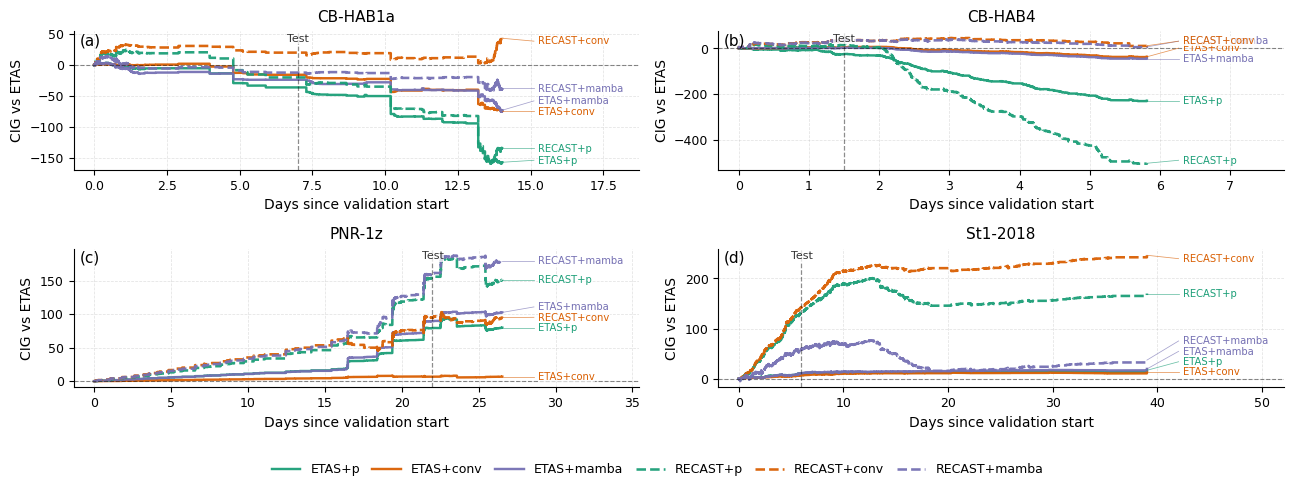

In [10]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, sharey=SHARE_Y)
axes = axes.ravel()

handles_by_label = {}
for panel_idx, (ax, item) in enumerate(zip(axes, loaded_datasets)):
    df = item['curve_df']
    labels = _label_order_for_df(df)
    start_days = item['plot_start_days']

    label_curve_map = {}
    for label in labels:
        prepared = _prepare_label_curve(df, label, start_days, reset_y=RESET_Y_AT_PLOT_START)
        if prepared is None:
            continue
        x, y = prepared
        line = ax.step(x, y, where='post', label=label, **_model_style(label))[0]
        handles_by_label.setdefault(label, line)
        label_curve_map[label] = (x, y, line)

    ax.axhline(0.0, color='black', linestyle='--', linewidth=0.8, alpha=0.45)
    ax.set_title(item['title'], fontsize=11, pad=7)
    ax.text(0.01, 0.99, _panel_label_from_index(panel_idx), transform=ax.transAxes, va='top', ha='left', fontsize=11)
    ax.set_xlabel(f'Days since {_format_start_label(PLOT_START_MODE)}', fontsize=10)
    ax.set_ylabel('CIG vs ETAS' if RESET_Y_AT_PLOT_START else 'CIG vs ETAS (cumulative)', fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.55, alpha=0.35)
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    _add_direct_curve_labels(ax, label_curve_map)
    _draw_split_markers(ax, item)

# Turn off unused axes if DATASET_CONFIGS changes.
for ax in axes[len(loaded_datasets):]:
    ax.axis('off')

legend_labels = [label for label in (MODEL_LABEL_ORDER or list(handles_by_label)) if label in handles_by_label]
legend_labels.extend([label for label in handles_by_label if label not in legend_labels])
legend_handles = [handles_by_label[label] for label in legend_labels]

fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.005),
    ncol=min(6, max(1, len(legend_labels))),
    fontsize=9,
    frameon=False,
    columnspacing=1.0,
    handlelength=2.3,
)

start_suffix = f'from_{PLOT_START_MODE}'
y_suffix = 'reset_y' if RESET_Y_AT_PLOT_START else 'absolute_y'
fig.tight_layout(rect=(0.02, 0.09, 0.965, 0.99))

fig_stem = f'cig_2x2_excluding_CCL_{SPLIT}_{SEQ_INDEX}_{start_suffix}_{y_suffix}'
pdf_path = FIG_EXPORT_DIR / f'{fig_stem}.pdf'
png_path = FIG_EXPORT_DIR / f'{fig_stem}.png'

if SAVE_PDF:
    fig.savefig(pdf_path, dpi=DPI, bbox_inches='tight')
if SAVE_PNG:
    fig.savefig(png_path, dpi=DPI, bbox_inches='tight')

print(f'Saved PDF: {pdf_path}')
print(f'Saved PNG: {png_path}')
plt.show()


## Optional: Save Cropped Long-Format Data

This cell exports the plotted 2×2 data after start-time cropping and optional y-reset, which is useful for downstream editing or reproduction.

In [11]:
EXPORT_CROPPED_CURVES = True
cropped_csv_path = METRIC_EXPORT_DIR / f'{fig_stem}_curves.csv'

if EXPORT_CROPPED_CURVES:
    rows = []
    for item in loaded_datasets:
        df = item['curve_df']
        labels = _label_order_for_df(df)
        start_days = item['plot_start_days']
        for label in labels:
            prepared = _prepare_label_curve(df, label, start_days, reset_y=RESET_Y_AT_PLOT_START)
            if prepared is None:
                continue
            x, y = prepared
            for xx, yy in zip(x, y):
                rows.append({
                    'dataset': item['dataset'],
                    'title': item['title'],
                    'label': label,
                    'days_since_plot_start': float(xx),
                    'plot_value': float(yy),
                    'plot_start_mode': PLOT_START_MODE,
                    'plot_start_days': float(start_days),
                    'reset_y_at_plot_start': bool(RESET_Y_AT_PLOT_START),
                    'source_curve_csv': str(item['curve_path'].relative_to(PROJECT_ROOT)),
                })
    cropped_df = pd.DataFrame(rows)
    cropped_df.to_csv(cropped_csv_path, index=False)
    print(f'Saved cropped curves CSV: {cropped_csv_path}')
    display(cropped_df.head())
else:
    print('EXPORT_CROPPED_CURVES=False; skipped CSV export.')


Saved cropped curves CSV: /root/autodl-tmp/em_eqf/notebooks/metrics/cumulative_likelihood_over_time/cig_2x2_excluding_CCL_test_0_from_val_reset_y_curves.csv


,dataset,title,label,days_since_plot_start,plot_value,plot_start_mode,plot_start_days,reset_y_at_plot_start,source_curve_csv
0,CB_HAB1a,CB-HAB1a,ETAS+p,0.000000,0.000000,val,32.724028,True,notebooks/metrics/cumulative_likelihood_over_t...
1,CB_HAB1a,CB-HAB1a,ETAS+p,0.000486,0.205078,val,32.724028,True,notebooks/metrics/cumulative_likelihood_over_t...
2,CB_HAB1a,CB-HAB1a,ETAS+p,0.000879,0.119141,val,32.724028,True,notebooks/metrics/cumulative_likelihood_over_t...
3,CB_HAB1a,CB-HAB1a,ETAS+p,0.000997,-0.013672,val,32.724028,True,notebooks/metrics/cumulative_likelihood_over_t...
4,CB_HAB1a,CB-HAB1a,ETAS+p,0.001284,-0.087891,val,32.724028,True,notebooks/metrics/cumulative_likelihood_over_t...
